In [44]:
import os
import cv2
import csv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [45]:
DATASET_DIR    = "ood_dataset_final"
IMG_SIZE       = 64
NUM_FRAMES     = 20
LATENT_DIM     = 256
BATCH_SIZE     = 16
TRAIN_SPLIT    = 0.8
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")


Using device: cpu


In [46]:
import zipfile
import os

zip_file_path = '/content/ood_dataset_final.zip'
extract_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted {zip_file_path} to {extract_dir}")

Extracted /content/ood_dataset_final.zip to /content/


In [47]:
# Same Dataset loading from model training
class CoRDataset(Dataset):
    def __init__(self, dataset_dir, labels_csv, meta_csv, npz_dir):
        self.dataset_dir = dataset_dir
        self.npz_dir = npz_dir

        # Load labels — sample_id, restitution, final_vel_ax, final_vel_bx
        self.labels = []
        with open(labels_csv, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.labels.append({
                    "sample_id":   row["sample_id"],
                    "restitution": float(row["restitution"]),
                    "vel_a_final": float(row["final_vel_ax"]),
                    "vel_b_final": float(row["final_vel_bx"]),
                })

        # Load initial velocities from metadata — needed for physics consistency loss
        self.meta = {}
        with open(meta_csv, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.meta[row["sample_id"]] = {
                    "vel_a_initial": float(row["initial_vel_ax"]),
                    "vel_b_initial": float(row["initial_vel_bx"]),
                }

        self.transform = transforms.Compose([
          transforms.ToTensor(),                        # (H,W,C) uint8 → (C,H,W) float [0,1]
          transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = self.labels[idx]
        sample_id = item["sample_id"]

        # Load video frames from MP4
        video_path = os.path.join(self.dataset_dir, "samples", f"{sample_id}.mp4")
        frames = self._load_npz(sample_id)

        # Retrieve initial velocities for physics consistency loss
        meta = self.meta.get(sample_id, {"vel_a_initial": 0.0, "vel_b_initial": 0.0})

        return {
            "frames":        frames,
            "cor":           torch.tensor(item["restitution"], dtype=torch.float32),
            "vel_a_final":   torch.tensor(item["vel_a_final"], dtype=torch.float32),
            "vel_b_final":   torch.tensor(item["vel_b_final"], dtype=torch.float32),
            "vel_a_initial": torch.tensor(meta["vel_a_initial"], dtype=torch.float32),
            "vel_b_initial": torch.tensor(meta["vel_b_initial"], dtype=torch.float32),
            "sample_id":     sample_id,
        }


    def _load_npz(self, sample_id):
      npz_path = os.path.join(self.npz_dir, f"{sample_id}.npz")
      data = np.load(npz_path)
      frames = data["frames"]  # (20, 64, 64, 3) uint8

      # Apply transform to each frame
      frame_tensors = [self.transform(frames[i]) for i in range(len(frames))]
      return torch.stack(frame_tensors)  # (20, 3, 64, 64)

In [48]:
# =================== MODEL ===================

class FrameCNN(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))    # 16×16 → 4×4, 128 channels → 128×16=2048

        self.fc = nn.Sequential(
            nn.Flatten(),                           # 128 × 4 × 4 = 2048
            nn.Linear(128 * 4 * 4, latent_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        # x: (batch, 3, H, W)
        x = self.conv_blocks(x)
        x = self.pool(x)
        x = self.fc(x)
        return x  # (batch, latent_dim)


In [49]:
import torchvision.models as models

class ResNetFrameEncoder(nn.Module):
    """
    Replaces FrameCNN with pretrained ResNet18 backbone.
    Removes final classification layer, keeps feature extractor.
    Output: 512-dim feature vector per frame (ResNet18 penultimate layer)
    Projected down to LATENT_DIM via linear layer.

    This class is now designed to be the full sequence encoder (ResNet + LSTM).
    """
    def __init__(self, latent_dim=LATENT_DIM, freeze_backbone=True):
        super().__init__()

        resnet = models.resnet18(pretrained=True)

        # Remove final FC layer — keep feature extractor only
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        # Output: (batch, 512, 1, 1) → flatten → (batch, 512)

        # Freeze backbone initially
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Project 512 → LATENT_DIM to match other architectures
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, latent_dim),
            nn.ReLU()
        )

        # Add LSTM for sequence processing, similar to CNNLSTMEncoder
        self.lstm = nn.LSTM(
            input_size=latent_dim,
            hidden_size=latent_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
        )

    def unfreeze_last_blocks(self):
        # Unfreeze layer3 and layer4 of ResNet18 for fine-tuning
        for name, param in self.backbone.named_parameters():
            if 'layer3' in name or 'layer4' in name:
                param.requires_grad = True

    def forward(self, x):
        # x: (batch, num_frames, 3, H, W)
        batch, num_frames, C, H, W = x.shape

        # Flatten batch and frames — process all frames simultaneously
        # (batch × num_frames, 3, H, W)
        x = x.view(batch * num_frames, C, H, W)

        # Run through ResNet backbone and FC layer to get frame latents
        # x: (batch × num_frames, latent_dim)
        x = self.backbone(x)
        x = self.fc(x)

        # Reshape back to sequence
        # (batch, num_frames, latent_dim)
        x = x.view(batch, num_frames, -1)

        # LSTM across time
        # output: (batch, num_frames, latent_dim)
        # h_n:    (num_layers, batch, latent_dim)
        _, (h_n, _) = self.lstm(x)

        # Take final layer's hidden state as the latent representation
        latent = h_n[-1]    # (batch, latent_dim)
        return latent

In [50]:
class CoRPredictor(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = ResNetFrameEncoder(latent_dim)

        # CoR head — output bounded to [0, 1] via sigmoid
        self.cor_head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # Velocity heads — signed floats, no activation
        self.vel_a_head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.vel_b_head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, num_frames, 3, H, W)
        latent = self.encoder(x)                        # (batch, latent_dim)

        cor_pred   = self.cor_head(latent).squeeze(-1).clamp(0.0,1.0)  # (batch,)
        vel_a_pred = self.vel_a_head(latent).squeeze(-1)
        vel_b_pred = self.vel_b_head(latent).squeeze(-1)

        return cor_pred, vel_a_pred, vel_b_pred, latent


In [51]:
class OODDataset(Dataset):
    def __init__(self, npz_dir, labels_csv):
        self.npz_dir = npz_dir
        self.labels = []
        with open(labels_csv, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.labels.append(row)

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.labels[idx]
        sample_id = f"sample_{int(row['sample_id']):05d}"
        npz_path = os.path.join(self.npz_dir, f"{sample_id}.npz")
        data = np.load(npz_path)
        frames = data["frames"]   # (20, 64, 64, 3) uint8
        frame_tensors = [self.transform(frames[i]) for i in range(len(frames))]
        frames_tensor = torch.stack(frame_tensors)  # (20, 3, 64, 64)
        if "mass_ratio" in row:
          extra = float(row["mass_ratio"])
        elif "offset" in row:
          extra = float(row["offset"])
        else:
          extra = 0.0
        return {
            "frames": frames_tensor,
            "cor":    torch.tensor(float(row["cor"]), dtype=torch.float32),
            "extra":  extra
            # "extra" is mass_ratio for unequal_mass, offset for off_centre
        }

In [52]:
def compute_metrics(cor_pred, cor_true):
    mae = np.mean(np.abs(cor_pred - cor_true))
    ss_res = np.sum((cor_true - cor_pred) ** 2)
    ss_tot = np.sum((cor_true - np.mean(cor_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return mae, r2

In [53]:
def plot_predictions(um_preds, um_cors, oc_preds, oc_cors):
    um_mae, um_r2 = compute_metrics(um_preds, um_cors)
    oc_mae, oc_r2 = compute_metrics(oc_preds, oc_cors)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Unequal Mass ---
    axes[0].scatter(um_cors, um_preds, alpha=0.5, color='green', s=20)
    axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
    axes[0].set_xlabel('True CoR')
    axes[0].set_ylabel('Predicted CoR')
    axes[0].set_title(f'Unequal Mass\nMAE={um_mae:.4f} | R²={um_r2:.4f}')
    axes[0].legend()
    axes[0].grid(True)

    # --- Off Centre ---
    axes[1].scatter(oc_cors, oc_preds, alpha=0.5, color='orange', s=20)
    axes[1].plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
    axes[1].set_xlabel('True CoR')
    axes[1].set_ylabel('Predicted CoR')
    axes[1].set_title(f'Off-Centre\nMAE={oc_mae:.4f} | R²={oc_r2:.4f}')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('ood_pred_vs_true.png', dpi=150)
    plt.show()
    print('Saved: ood_pred_vs_true.png')

In [54]:
import zipfile
import os

zip_file_path = '/content/dataset_final.zip'
extract_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted {zip_file_path} to {extract_dir}")

Extracted /content/dataset_final.zip to /content/


In [55]:
# =================== MOMENTUM CONSERVATION PROBE ===================

def momentum_conservation_probe(model, test_loader, device):
    model.eval()

    momentum_before_all = []
    momentum_after_all  = []
    residuals_all       = []
    cor_true_all        = []

    with torch.no_grad():
        for batch in test_loader:
            frames     = batch["frames"].to(device)
            vel_a_init = batch["vel_a_initial"].to(device)
            vel_b_init = batch["vel_b_initial"].to(device)
            cor_true   = batch["cor"]

            _, vel_a_pred, vel_b_pred, _ = model(frames)

            # Total momentum before and after (equal masses = 1.0)
            momentum_before = vel_a_init + vel_b_init
            momentum_after  = vel_a_pred + vel_b_pred
            residual        = torch.abs(momentum_after - momentum_before)

            momentum_before_all.append(momentum_before.cpu())
            momentum_after_all.append(momentum_after.cpu())
            residuals_all.append(residual.cpu())
            cor_true_all.append(cor_true)

    momentum_before_all = torch.cat(momentum_before_all).numpy()
    momentum_after_all  = torch.cat(momentum_after_all).numpy()
    residuals_all       = torch.cat(residuals_all).numpy()
    cor_true_all        = torch.cat(cor_true_all).numpy()

    # ---- Print summary ----
    mean_momentum_magnitude = np.abs(momentum_before_all).mean()
    relative_error = residuals_all.mean() / (mean_momentum_magnitude + 1e-8) * 100

    print("=" * 55)
    print("MOMENTUM CONSERVATION PROBE")
    print("=" * 55)
    print(f"Mean momentum before : {momentum_before_all.mean():.4f}")
    print(f"Mean momentum after  : {momentum_after_all.mean():.4f}")
    print(f"Mean residual        : {residuals_all.mean():.4f}")
    print(f"Median residual      : {np.median(residuals_all):.4f}")
    print(f"Max residual         : {residuals_all.max():.4f}")
    print(f"% samples residual < 5  : {(residuals_all < 5).mean()*100:.1f}%")
    print(f"% samples residual < 10 : {(residuals_all < 10).mean()*100:.1f}%")
    print(f"Mean |momentum before|   : {mean_momentum_magnitude:.2f}")
    print(f"Relative momentum error  : {relative_error:.2f}%")
    print()
    if relative_error < 5.0:
        print("✓ Model satisfies momentum conservation (<5% relative error)")
    elif relative_error < 10.0:
        print("~ Model approximately satisfies momentum conservation (5-10%)")
    else:
        print("✗ Model does not satisfy momentum conservation (>10%)")
    print("=" * 55)

    # ---- Plots ----
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: Momentum before vs after
    ax = axes[0]
    ax.scatter(momentum_before_all, momentum_after_all,
               c=cor_true_all, cmap="RdYlBu_r", alpha=0.5, s=15)
    lim = [momentum_before_all.min() - 10, momentum_before_all.max() + 10]
    ax.plot(lim, lim, "r--", linewidth=2, label="Perfect conservation (y=x)")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Total Momentum Before\n(vel_a_init + vel_b_init)", fontsize=10)
    ax.set_ylabel("Predicted Total Momentum After\n(vel_a_pred + vel_b_pred)", fontsize=10)
    ax.set_title("Momentum Conservation:\nPredicted vs True", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.88,
            f"Mean residual: {residuals_all.mean():.2f}\n"
            f"Relative error: {relative_error:.1f}%",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

    # Plot 2: Distribution of residuals
    ax = axes[1]
    ax.hist(residuals_all, bins=40, color="steelblue",
            edgecolor="white", alpha=0.8)
    ax.axvline(residuals_all.mean(), color="red", linewidth=2,
               linestyle="--", label=f"Mean = {residuals_all.mean():.2f}")
    ax.axvline(np.median(residuals_all), color="orange", linewidth=2,
               linestyle="--", label=f"Median = {np.median(residuals_all):.2f}")
    ax.set_xlabel("Momentum Residual |p_after - p_before|", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title("Distribution of\nMomentum Conservation Error", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Plot 3: Residual vs CoR
    ax = axes[2]
    ax.scatter(cor_true_all, residuals_all,
               alpha=0.4, s=15, color="steelblue")
    cor_bins = np.arange(0.0, 1.1, 0.1)
    bin_means   = []
    bin_centers = []
    for i in range(len(cor_bins) - 1):
        mask = (cor_true_all >= cor_bins[i]) & (cor_true_all < cor_bins[i+1])
        if mask.sum() > 0:
            bin_means.append(residuals_all[mask].mean())
            bin_centers.append((cor_bins[i] + cor_bins[i+1]) / 2)
    ax.plot(bin_centers, bin_means, "ro-", linewidth=2,
            markersize=8, label="Mean per CoR bin")
    ax.set_xlabel("True CoR", fontsize=10)
    ax.set_ylabel("Momentum Residual", fontsize=10)
    ax.set_title("Momentum Error Across CoR Values\n"
                 "(Flat line = elasticity-independent conservation)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.88,
            "Flat line = model respects\nmomentum conservation\nindependently of CoR",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

    plt.suptitle(
        "Momentum Conservation Probe — Architecture 3 (3D CNN)\n"
        "Model was never trained on this law. Does it satisfy it anyway?",
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.savefig("momentum_conservation_arch3.png", dpi=150, bbox_inches="tight")
    plt.show()

    return residuals_all, relative_error

Loading model...
Model loaded.
Loading unequal mass OOD dataset...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Unequal mass: 200 samples
Loading off-centre OOD dataset...
Off-centre: 200 samples
Loading real test set...
Real test set: 660 samples

Scenario                  MAE       R²
Real test set          0.0434   0.9708
Unequal mass           0.0549   0.9457
Off-centre             0.1749   0.3996

Generating plots...


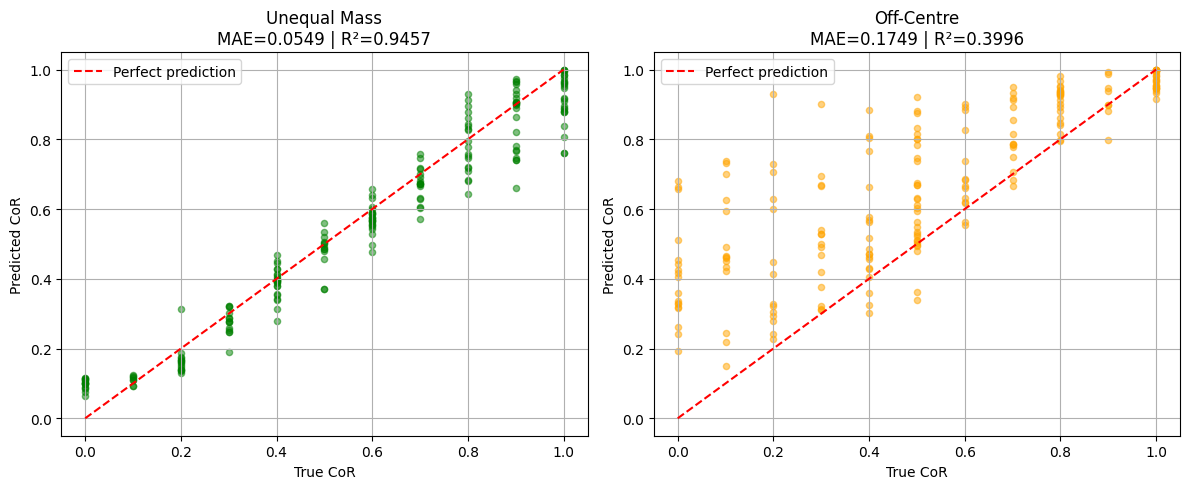

Saved: ood_pred_vs_true.png

OOD analysis complete.
MOMENTUM CONSERVATION PROBE
Mean momentum before : 0.4576
Mean momentum after  : 0.0241
Mean residual        : 5.8409
Median residual      : 4.7335
Max residual         : 38.7717
% samples residual < 5  : 53.3%
% samples residual < 10 : 84.1%
Mean |momentum before|   : 40.12
Relative momentum error  : 14.56%

✗ Model does not satisfy momentum conservation (>10%)


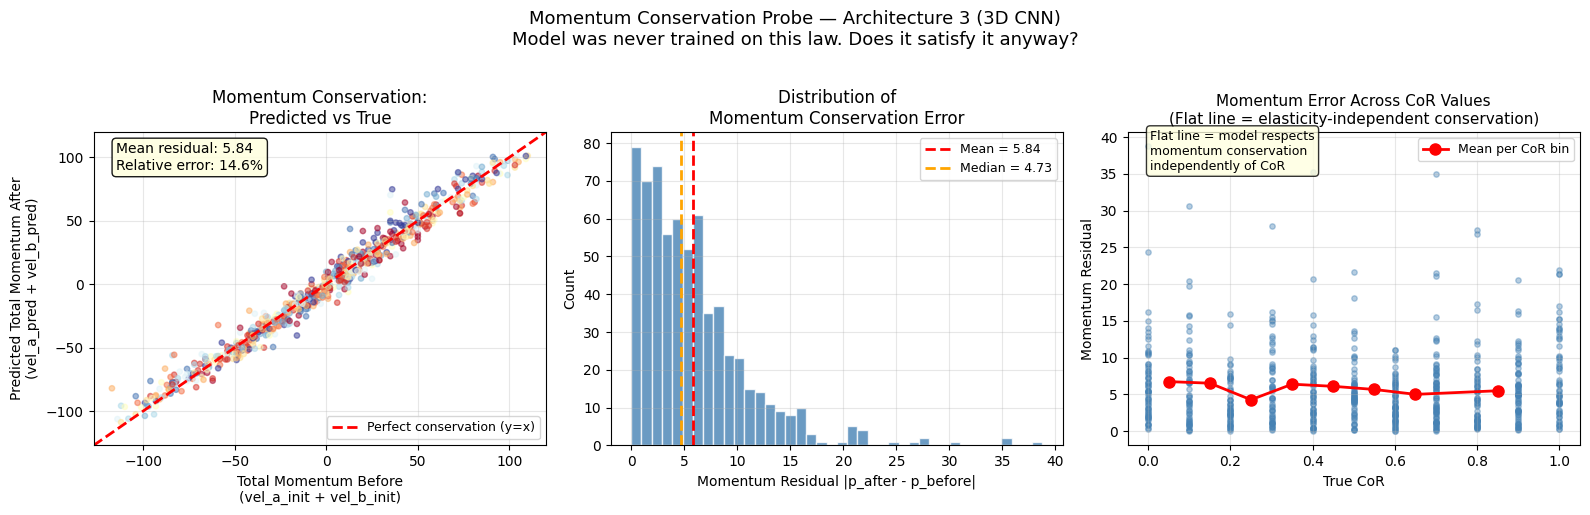

In [56]:
def extract_latents(model, loader, device):
    model.eval()
    latents, cor_preds, cor_trues, extras_list = [], [], [], []
    has_extra_in_any_batch = False # Flag to track if 'extra' was found in any batch

    with torch.no_grad():
        for batch in loader:
            frames = batch["frames"].to(device)
            cor_pred, _, _, latent = model(frames)
            latents.append(latent.cpu().numpy())
            cor_preds.append(cor_pred.cpu().numpy())
            cor_trues.append(batch["cor"].numpy())

            if "extra" in batch:
                extras_list.append(batch["extra"].numpy())
                has_extra_in_any_batch = True

    # Concatenate results
    if latents: # Ensure latents is not empty before concatenating
        latents = np.concatenate(latents)
        cor_preds = np.concatenate(cor_preds)
        cor_trues = np.concatenate(cor_trues)
    else: # Handle case of empty loader gracefully
        latents = np.array([])
        cor_preds = np.array([])
        cor_trues = np.array([])

    if has_extra_in_any_batch:
        extras = np.concatenate(extras_list)
    else:
        extras = np.array([]) # Return an empty numpy array if no 'extra' was found in any batch

    return latents, cor_preds, cor_trues, extras

def main():
    # ---- Load model ----
    print("Loading model...")
    model = CoRPredictor(latent_dim=LATENT_DIM).to(DEVICE)
    model.load_state_dict(torch.load("best_arch4_v2.pt", map_location=DEVICE))
    model.eval()
    print("Model loaded.")



    # ---- Load unequal mass OOD ----
    print("Loading unequal mass OOD dataset...")
    um_dataset = OODDataset(
        npz_dir    = f"ood_dataset/unequal_mass/npz_samples",
        labels_csv = f"ood_dataset/unequal_mass/labels.csv"
    )
    um_loader = DataLoader(um_dataset, batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2)
    um_latents, um_preds, um_cors, um_extras = extract_latents(model, um_loader, DEVICE)
    print(f"Unequal mass: {len(um_cors)} samples")

    # ---- Load off-centre OOD ----
    print("Loading off-centre OOD dataset...")
    oc_dataset = OODDataset(
        npz_dir    = f"ood_dataset/off_centre/npz_samples",
        labels_csv = f"ood_dataset/off_centre/labels.csv"
    )
    oc_loader = DataLoader(oc_dataset, batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2)
    oc_latents, oc_preds, oc_cors, oc_extras = extract_latents(model, oc_loader, DEVICE)
    print(f"Off-centre: {len(oc_cors)} samples")

    # ---- Load real test set ----
    print("Loading real test set...")
    real_dataset = CoRDataset(
        dataset_dir = "dataset2",
        labels_csv  = "dataset2/labels.csv",
        meta_csv    = "dataset2/scene_metadata.csv",
        npz_dir     = "dataset2/npz_samples"
    )
    n_train = int(len(real_dataset) * TRAIN_SPLIT)
    n_test  = len(real_dataset) - n_train
    _, test_set = random_split(
        real_dataset, [n_train, n_test],
        generator=torch.Generator().manual_seed(42)  # same seed as training
    )
    real_loader = DataLoader(test_set, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=2)
    real_latents, real_preds, real_cors, _ = extract_latents(model, real_loader, DEVICE)
    print(f"Real test set: {len(real_cors)} samples")

    # ---- Metrics ----
    real_mae, real_r2 = compute_metrics(real_preds, real_cors)
    um_mae,   um_r2   = compute_metrics(um_preds,   um_cors)
    oc_mae,   oc_r2   = compute_metrics(oc_preds,   oc_cors)

    print("\n" + "="*55)
    print(f"{'Scenario':<20} {'MAE':>8} {'R²':>8}")
    print("="*55)
    print(f"{'Real test set':<20} {real_mae:>8.4f} {real_r2:>8.4f}")
    print(f"{'Unequal mass':<20} {um_mae:>8.4f} {um_r2:>8.4f}")
    print(f"{'Off-centre':<20} {oc_mae:>8.4f} {oc_r2:>8.4f}")
    print("="*55)

    # ---- Plots ----
    print("\nGenerating plots...")
    plot_predictions(um_preds, um_cors, oc_preds, oc_cors)
    print("\nOOD analysis complete.")

    residuals, rel_error = momentum_conservation_probe(model, real_loader, DEVICE)

if __name__ == "__main__":
    main()